# Charged Black Holes in Entangled Relativity
## Arnaud Crepinge - M2 Internship

### Null Geodesics Analysis

### Normalizing wrt Mass

In [1]:
# Import libraries

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from scipy.integrate import quad

# Font for plotting

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})

## 1 - Definitions

In [2]:
# Horizons in GR

def rpm_GR(M, Q):
    sqrt = sp.sqrt if isinstance(M, sp.Basic) else np.sqrt
    disc = sqrt(M**2 - Q**2)
    return M + disc, M - disc

# Horizons in ER

def rpm_ER(M, Q):
    disc = np.sqrt(M**2 - (11/12) * Q**2)
    return M + disc, (13/11) * (M - disc)

def rpm_ER_sym(M, Q):
    disc = sp.sqrt(M**2 - sp.Rational(11, 12) * Q**2)
    return M + disc, sp.Rational(13, 11) * (M - disc)

# Effective Potential in GR

def Veff_GR(r, M, Q):
    rp, rm = rpm_GR(M,Q)
    return (1 / r**2) * (1 - rm/r) * (1 - rp/r)

# Effective Potential in ER

def Veff_ER(r, M, Q):
    rp, rm = rpm_ER(M,Q)
    return (1 / r**2) * (1 - rp/r) * (1 - rm/r)**(9/13)

# Areal radius ρ as a function of coordinate radius r
# In GR : g_φφ = r² sin²θ  →  ρ = r
# In ER : g_φφ = r²(1 - rm/r)^(2/13) sin²θ  →  ρ = r(1 - rm/r)^(1/13)

def rho_GR(r, M, Q): 
    return r
    
def rho_ER(r, M, Q):
    _, rm = rpm_ER(M, Q)
    return r * (1 - rm / r) ** (1 / 13)

def r_coord(rho, M, Q):
    rp, rm = rpm_ER(M, Q)
    if np.isclose(Q, 0):
        return rho
    if np.isclose(rho, 0):
        return rm
    return brentq(lambda x: rho_ER(x, M, Q) - rho, rm, rho + 2*rp)

# Derivative of rho wrt r

def drho_dr_GR(r, M, Q):
    return 1

def drho_dr_ER(r, M, Q):
    _, rm = rpm_ER(M, Q)
    u = (1 - rm / r)**(-12/13)
    return u * (1 - (12 * rm) / (13 * r))

### Computing the Christoffel Symbols

In [3]:
# Coordinates & Parameters

t, r, th, ph = sp.symbols('t r theta phi', real=True, positive=True)
M, Q         = sp.symbols('M Q', real=True, positive=True)

coords  = [t, r, th, ph]
params  = [M, Q]
all_sym = coords + params

# Metric for GR -> Reissner-Nordström

rp_GR, rm_GR = rpm_GR(M,Q)
f = (1 - rm_GR/r) * (1 - rp_GR/r)

g_GR = sp.Matrix([
    [-f, 0, 0, 0],
    [0, 1/f, 0, 0],
    [0, 0, r**2, 0],
    [0, 0, 0, r**2 * sp.sin(th)**2]
])

# Metric for ER

rp_ER, rm_ER = rpm_ER_sym(M,Q)
f = (1 - rp_ER/r) * (1 - rm_ER/r)**sp.Rational(11, 13)
f2 = (1 - rm_ER/r)**sp.Rational(2, 13)

g_ER = sp.Matrix([
    [-f, 0, 0, 0],
    [0, 1/f, 0, 0],
    [0, 0, r**2 * f2, 0],
    [0, 0, 0, r**2 * sp.sin(th)**2 * f2]
])

# Computing Christoffel Symbols

def compute_christoffel_sym(g, coords):
    n   = len(coords)
    g_inv = g.inv()
    
    # ∂_σ g_μν  — precomputed once
    dg = [[[sp.diff(g[m, n_], coords[s]) for s in range(n)]
            for n_ in range(n)]
           for m in range(n)]
    
    G = [[[None]*n for _ in range(n)] for _ in range(n)]
    for mu in range(n):
        for al in range(n):
            for be in range(al, n):          # exploit symmetry Γ^μ_αβ = Γ^μ_βα
                s = sum(
                    g_inv[mu, nu] * (dg[nu][be][al] + dg[nu][al][be] - dg[al][be][nu])
                    for nu in range(n)
                )
                expr = sp.radsimp(sp.powsimp(s / 2, force=True))
                G[mu][al][be] = expr
                G[mu][be][al] = expr         # symmetry copy
    return G

print("Computing Christoffel symbols for GR... ", end="", flush=True)
G_GR = compute_christoffel_sym(g_GR, coords)
print("Computing Christoffel symbols for ER... ", end="", flush=True)
G_ER = compute_christoffel_sym(g_ER, coords)
print("done")

Computing Christoffel symbols for GR... Computing Christoffel symbols for ER... done


In [4]:
# Lambdify to obtain functions

G_num_GR = sp.lambdify(all_sym, sp.Array(G_GR), "numpy")
G_num_ER = sp.lambdify(all_sym, sp.Array(G_ER), "numpy")

g_num_GR = sp.lambdify(all_sym, g_GR, "numpy")

g_num_ER = sp.lambdify(all_sym, g_ER, "numpy")

### Solving Equations

In [5]:
def geodesic_rhs(lam, state, G_num, M_val, Q_val): 
    x = state[:4]
    k = state[4:]
    args = (*x, M_val, Q_val)

    G = np.array(G_num(*args), dtype=float)  # single call, 64x fewer Python-level dispatches

    # Faster — pure NumPy
    dk = -np.einsum('mab,a,b->m', G, k, k)
    return np.concatenate([k, dk])


def fix_kt(x0, kr, kth, kph, g_num, M_val, Q_val):
    args  = (*x0, M_val, Q_val)
    g_mat = np.array(g_num(*args), dtype=float)
    A = -g_mat[0, 0]
    B = g_mat[1,1]*kr**2 + g_mat[2,2]*kth**2 + g_mat[3,3]*kph**2
    return np.sqrt(B / A)

# Check normalization

def check_normalization(sol, g_num, M_val, Q_val, target=0.0):
    norms = np.zeros(sol.y.shape[1])
    for i in range(sol.y.shape[1]):
        x = sol.y[:4, i]
        k = sol.y[4:, i]
        g = np.array(g_num(*x, M_val, Q_val), dtype=float)
        norms[i] = np.einsum('mn,m,n->', g, k, k)
    return norms - target   # deviation from expected value

## 2 - Plotting Trajectories

In [ ]:
### ── Parameters ────────────────────────────────────────────────────────────────
# Format: (M, Q, color, label)
cases = [
    (1.0, 0.0, 'black',  r'$Q/M = 0.0$'),
    (1.0, 0.1, 'purple', r'$Q/M = 0.1$'),
    (1.0, 0.3, 'pink',   r'$Q/M = 0.3$'),
    (1.0, 0.5, 'blue',   r'$Q/M = 0.5$'),
    (1.0, 0.7, 'green',   r'$Q/M = 0.7$'),
    (1.0, 0.9, 'orange', r'$Q/M = 0.9$'),
    (1.0, 1.0, 'red',    r'$Q/M = 1.0$')
]

### In r coordinate

In [ ]:
r_init = 3.0 # Must be strictly greater than 2 (Schwarzschild horizon)

# Areal radius Initial Conditions
kr_init   = 0   # Radial velocity
kph_init  = 1   # Angular velocity

# ── Absorption event factory ───────────────────────────────────────────────────
def make_absorption_event(rp_val):
    def absorbed(lam, s):
        return s[1] - rp_val * 1.005  # Stops just outside the coordinate horizon
    absorbed.terminal  = True
    absorbed.direction = -1
    return absorbed

# ── Solver ────────────────────────────────────────────────────────────────────
def solve_geodesic(G_num, g_num, rpm_func, M_val, Q_val, kr, kph, r0, lam_max=20, n_pts=20000):
    x0 = np.array([0.0, r0, np.pi/2, 0.0])
    kt = fix_kt(x0, kr, 0.0, kph, g_num, M_val, Q_val)
    k0 = np.array([kt, kr, 0.0, kph])

    rp, _ = rpm_func(M_val, Q_val)
    event = make_absorption_event(float(rp))

    sol = solve_ivp(
        fun=lambda lam, s: geodesic_rhs(lam, s, G_num, M_val, Q_val),
        t_span=(0, lam_max),
        y0=np.concatenate([x0, k0]),
        t_eval=np.linspace(0, lam_max, n_pts),
        method="DOP853",
        rtol=1e-10, atol=1e-12,
        events=event,
    )
    return sol

# ── Plot Setup ────────────────────────────────────────────────────────────────
theories = [
    ("GR", G_num_GR, g_num_GR, rpm_GR, rho_GR, drho_dr_GR, '--'),
    ("ER", G_num_ER, g_num_ER, rpm_ER, rho_ER, drho_dr_ER, '-'),
]

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(9, 9))
ax.set_rlabel_position(270)

theta_circle = np.linspace(0, 2*np.pi, 500)

# ── Integrate and Plot ────────────────────────────────────────────────────────
for M_val, Q_val, color, label in cases:
    for theory_name, G_num, g_num, rpm_func, rho_func, drho_dr_func, linestyle in theories:

        # 1. Calculate the physical outer horizon (rho_+) for this specific case
        rp_coord, _ = rpm_func(M_val, Q_val)
        rho_plus = rho_func(rp_coord, M_val, Q_val)

        # 2. Dynamically define the injection point
        rho0_local = rho_init * M_val

        # 3. Map that case-specific areal radius to the required coordinate r0
        if theory_name == "GR":
            r0_init = rho0_local
        else:
            r0_init = r_coord(rho0_local, M_val, Q_val)

        kr = krho_init / drho_dr_func(r0_init, M_val, Q_val)
        kph = kph_init

        # 4. Solve the geodesic equations in terms of coordinate r
        sol = solve_geodesic(G_num, g_num, rpm_func, M_val, Q_val, kr, kph, r0=r0_init)

        # 5. Map coordinate r back to physical rho, then scale by M
        rho_trajectory = rho_func(sol.y[1], M_val, Q_val)
        rho_scaled = rho_trajectory / M_val
        phi_trajectory = sol.y[3]

        # (draws a thin horizon ring for each case × theory, in matching color)
        ax.plot(theta_circle, np.full_like(theta_circle, rho_plus / M_val),
                color=color, lw=1.5, linestyle=linestyle, alpha=0.7, zorder=5)

        # 6. Plot the mass-scaled physical trajectory
        ax.plot(phi_trajectory, rho_scaled,
                color=color, lw=1.5, linestyle=linestyle, zorder=4)

        if sol.status == 1:
            ax.plot(phi_trajectory[-1], rho_scaled[-1],
                    'x', color=color, ms=6, zorder=6)

# ── Custom Legends ────────────────────────────────────────────────────────────
color_handles = [Line2D([0], [0], color=c, lw=2, label=lbl) for _, _, c, lbl in cases]
style_handles = [
    Line2D([0], [0], color='black', lw=2, linestyle='--', label=r'GR'),
    Line2D([0], [0], color='black', lw=2, linestyle='-', label=r'ER')
]
handles = color_handles + style_handles
ax.legend(handles=handles, loc="upper right", fontsize=12, framealpha=0.7)

# Set radial limits to focus on the action near the photon sphere
ax.set_rmax(1.5*rho_init)

plt.tight_layout()
plt.savefig("images/NullGeodesics_Mass.png", dpi=150, bbox_inches='tight')

### In rho coordinate

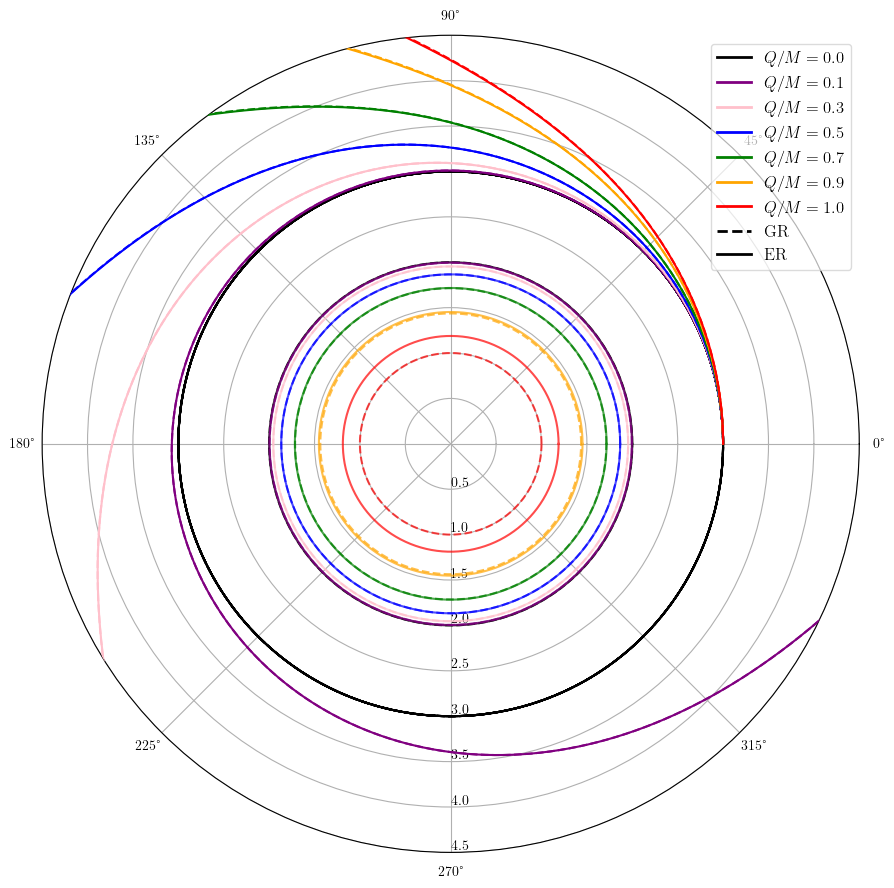

In [6]:
rho_init = 3.0 # Must be strictly greater than 2 (Schwarzschild horizon)

# Areal radius Initial Conditions
krho_init   = 0   # Radial velocity
kph_init  = 1   # Angular velocity

# ── Absorption event factory ───────────────────────────────────────────────────
def make_absorption_event(rp_val):
    def absorbed(lam, s):
        return s[1] - rp_val * 1.005  # Stops just outside the coordinate horizon
    absorbed.terminal  = True
    absorbed.direction = -1
    return absorbed

# ── Solver ────────────────────────────────────────────────────────────────────
def solve_geodesic(G_num, g_num, rpm_func, M_val, Q_val, kr, kph, r0, lam_max=20, n_pts=20000):
    x0 = np.array([0.0, r0, np.pi/2, 0.0])
    kt = fix_kt(x0, kr, 0.0, kph, g_num, M_val, Q_val)
    k0 = np.array([kt, kr, 0.0, kph])

    rp, _ = rpm_func(M_val, Q_val)
    event = make_absorption_event(float(rp))

    sol = solve_ivp(
        fun=lambda lam, s: geodesic_rhs(lam, s, G_num, M_val, Q_val),
        t_span=(0, lam_max),
        y0=np.concatenate([x0, k0]),
        t_eval=np.linspace(0, lam_max, n_pts),
        method="DOP853",
        rtol=1e-10, atol=1e-12,
        events=event,
    )
    return sol

# ── Plot Setup ────────────────────────────────────────────────────────────────
theories = [
    ("GR", G_num_GR, g_num_GR, rpm_GR, rho_GR, drho_dr_GR, '--'),
    ("ER", G_num_ER, g_num_ER, rpm_ER, rho_ER, drho_dr_ER, '-'),
]

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(9, 9))
ax.set_rlabel_position(270)

theta_circle = np.linspace(0, 2*np.pi, 500)

# ── Integrate and Plot ────────────────────────────────────────────────────────
for M_val, Q_val, color, label in cases:
    for theory_name, G_num, g_num, rpm_func, rho_func, drho_dr_func, linestyle in theories:

        # 1. Calculate the physical outer horizon (rho_+) for this specific case
        rp_coord, _ = rpm_func(M_val, Q_val)
        rho_plus = rho_func(rp_coord, M_val, Q_val)

        # 2. Dynamically define the injection point
        rho0_local = rho_init * M_val

        # 3. Map that case-specific areal radius to the required coordinate r0
        if theory_name == "GR":
            r0_init = rho0_local
        else:
            r0_init = r_coord(rho0_local, M_val, Q_val)

        kr = krho_init / drho_dr_func(r0_init, M_val, Q_val)
        kph = kph_init

        # 4. Solve the geodesic equations in terms of coordinate r
        sol = solve_geodesic(G_num, g_num, rpm_func, M_val, Q_val, kr, kph, r0=r0_init)

        # 5. Map coordinate r back to physical rho, then scale by M
        rho_trajectory = rho_func(sol.y[1], M_val, Q_val)
        rho_scaled = rho_trajectory / M_val
        phi_trajectory = sol.y[3]

        # (draws a thin horizon ring for each case × theory, in matching color)
        ax.plot(theta_circle, np.full_like(theta_circle, rho_plus / M_val),
                color=color, lw=1.5, linestyle=linestyle, alpha=0.7, zorder=5)

        # 6. Plot the mass-scaled physical trajectory
        ax.plot(phi_trajectory, rho_scaled,
                color=color, lw=1.5, linestyle=linestyle, zorder=4)

        if sol.status == 1:
            ax.plot(phi_trajectory[-1], rho_scaled[-1],
                    'x', color=color, ms=6, zorder=6)

# ── Custom Legends ────────────────────────────────────────────────────────────
color_handles = [Line2D([0], [0], color=c, lw=2, label=lbl) for _, _, c, lbl in cases]
style_handles = [
    Line2D([0], [0], color='black', lw=2, linestyle='--', label=r'GR'),
    Line2D([0], [0], color='black', lw=2, linestyle='-', label=r'ER')
]
handles = color_handles + style_handles
ax.legend(handles=handles, loc="upper right", fontsize=12, framealpha=0.7)

# Set radial limits to focus on the action near the photon sphere
ax.set_rmax(1.5*rho_init)

plt.tight_layout()
plt.savefig("images/NullGeodesics_Mass.png", dpi=150, bbox_inches='tight')

### Fixed Impact Parameter

Skipped GR, Q/M=1.00: b/M=4.500 not allowed at rho0/M=3.0


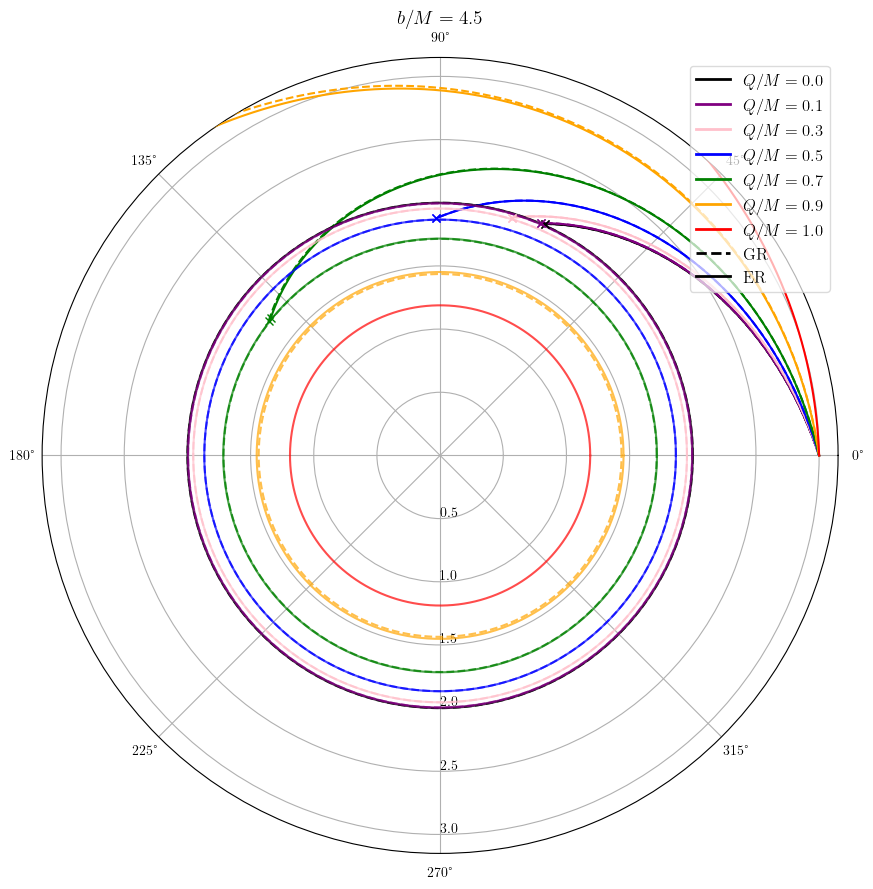

In [7]:
# ── Trajectories at fixed impact parameter b ─────────────────────────────────

b_over_M = 4.5      # Choose common impact parameter b/M
E_val = 1.0         # Only fixes affine parametrization
radial_sign = -1    # -1 inward, +1 outward
angular_sign = +1   # +1 counterclockwise, -1 clockwise

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(9, 9))
ax.set_rlabel_position(270)

theta_circle = np.linspace(0, 2*np.pi, 500)

def initial_k_from_b(g_num, M_val, Q_val, r0, b, E=1.0, radial_sign=-1, angular_sign=+1):
    """
    Build initial photon 4-velocity from fixed impact parameter b = |L|/E.

    Metric convention:
        ds² = -A dt² + B dr² + C dφ²
    Equatorial plane:
        θ = π/2
    """
    x0 = np.array([0.0, r0, np.pi/2, 0.0])
    g = np.array(g_num(*x0, M_val, Q_val), dtype=float)

    A = -g[0, 0]
    B =  g[1, 1]
    C =  g[3, 3]

    L = angular_sign * b * E

    kt  = E / A
    kph = L / C

    radicand = (E**2 / A - L**2 / C) / B

    if radicand < 0:
        return None

    kr = radial_sign * np.sqrt(radicand)

    return kt, kr, kph


for M_val, Q_val, color, label in cases:

    b_val = b_over_M * M_val

    for theory_name, G_num, g_num, rpm_func, rho_func, drho_dr_func, linestyle in theories:

        # Horizon
        rp_coord, _ = rpm_func(M_val, Q_val)
        rho_plus = rho_func(rp_coord, M_val, Q_val)

        # Same initial areal radius rho0 for both theories
        rho0_local = rho_init * M_val

        if theory_name == "GR":
            r0_init = rho0_local
        else:
            r0_init = r_coord(rho0_local, M_val, Q_val)

        # Initial k from common impact parameter b
        k_init = initial_k_from_b(
            g_num,
            M_val,
            Q_val,
            r0_init,
            b=b_val,
            E=E_val,
            radial_sign=radial_sign,
            angular_sign=angular_sign
        )

        if k_init is None:
            print(f"Skipped {theory_name}, Q/M={Q_val/M_val:.2f}: b/M={b_over_M:.3f} not allowed at rho0/M={rho_init}")
            continue

        kt, kr, kph = k_init

        # Optional diagnostic: corresponding areal radial component
        krho = drho_dr_func(r0_init, M_val, Q_val) * kr

        # Solve using coordinate components
        sol = solve_geodesic(
            G_num,
            g_num,
            rpm_func,
            M_val,
            Q_val,
            kr=kr,
            kph=kph,
            r0=r0_init
        )

        # Convert trajectory to areal radius
        rho_trajectory = rho_func(sol.y[1], M_val, Q_val)
        rho_scaled = rho_trajectory / M_val
        phi_trajectory = sol.y[3]

        # Horizon ring
        ax.plot(
            theta_circle,
            np.full_like(theta_circle, rho_plus / M_val),
            color=color,
            lw=1.5,
            linestyle=linestyle,
            alpha=0.7,
            zorder=5
        )

        # Trajectory
        ax.plot(
            phi_trajectory,
            rho_scaled,
            color=color,
            lw=1.5,
            linestyle=linestyle,
            zorder=4
        )

        if sol.status == 1:
            ax.plot(
                phi_trajectory[-1],
                rho_scaled[-1],
                'x',
                color=color,
                ms=6,
                zorder=6
            )

# ── Legends ──────────────────────────────────────────────────────────────────

ax.legend(handles=handles, loc="upper right", fontsize=12, framealpha=0.7)

ax.set_title(rf'$b/M = {b_over_M}$', fontsize=14)
ax.set_rlim(0, rho_init * 1.05)

plt.tight_layout()
#plt.savefig(f"images/NullGeodesics_FixedImpact_b{b_over_M:.2f}.png", dpi=150, bbox_inches='tight')

### Numerical Error Plot

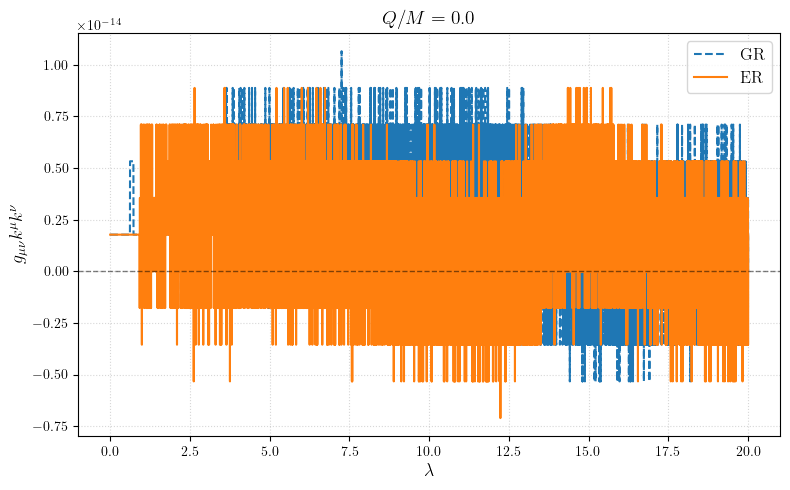

In [8]:
# ── Parameters ────────────────────────────────────────────────────────────────
Q_norm = 0.

# Setup a single panel plot
fig, ax = plt.subplots(figsize=(8, 5))

# ── Integrate and Track Normalization ─────────────────────────────────────────
for theory_name, G_num, g_num, rpm_func, rho_func, drho_dr_func, linestyle in theories:
    
    # 1. Dynamically calculate the matching initial coordinate radius r0
    rp_coord, _ = rpm_func(1.0, Q_norm)
    rho_plus = rho_func(rp_coord, 1.0, Q_norm)
    rho0_local = rho_init # M = 1

    kr = krho_init / drho_dr_func(r_coord(rho0_local, 1, Q_norm), 1, Q_norm)
    kph = kph_init
    
    if theory_name == "GR":
        r0_init = rho0_local
    else:
        r0_init = r_coord(rho0_local, 1.0, Q_norm)

    # 2. Solve the geodesic system
    sol = solve_geodesic(G_num, g_num, rpm_func, 1.0, Q_norm, kr, kph, r0=r0_init)
    
    # 3. Calculate the actual constraint deviation (should theoretically be 0.0)
    residuals = check_normalization(sol, g_num, 1.0, Q_norm, target=0.0)

    # 4. Plot tracking over the affine parameter lambda
    ax.plot(sol.t, residuals, linestyle=linestyle, lw=1.5, label=theory_name)

# ── Plot Styling ──────────────────────────────────────────────────────────────
ax.set_xlabel(r"$\lambda$", fontsize=13)
ax.set_ylabel(r"$g_{\mu\nu}k^\mu k^\nu$", fontsize=13)
ax.set_title(f"$Q/M = {Q_norm}$", fontsize=14)

# Draw an explicit ideal baseline at 0
ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)

ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()

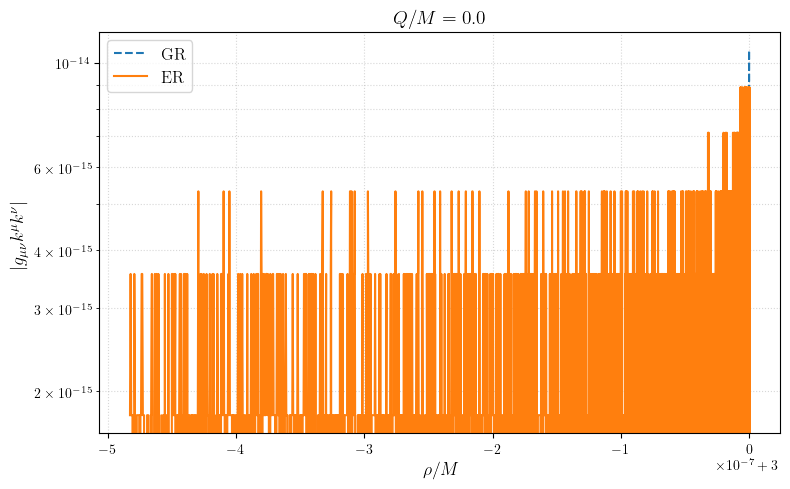

In [9]:
# ── Parameters ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# ── Integrate and Track Normalization vs Radius ───────────────────────────────
for theory_name, G_num, g_num, rpm_func, rho_func, drho_dr_func, linestyle in theories:
    
    # 1. Dynamically calculate matching initial coordinate radius r0
    rp_coord, _ = rpm_func(1.0, Q_norm)
    rho_plus = rho_func(rp_coord, 1.0, Q_norm)
    rho0_local = rho_init # M = 1

    kr = krho_init / drho_dr_func(r_coord(rho0_local, 1, Q_norm), 1, Q_norm)
    kph = kph_init
    
    if theory_name == "GR":
        r0_init = rho0_local
    else:
        r0_init = r_coord(rho0_local, 1.0, Q_norm)

    # 2. Solve the geodesic system
    sol = solve_geodesic(G_num, g_num, rpm_func, 1.0, Q_norm, kr, kph, r0=r0_init)
    
    # 3. Extract physical areal radius profile and constraint residuals
    rho_trajectory = rho_func(sol.y[1], 1.0, Q_norm) 
    residuals = check_normalization(sol, g_num, 1.0, Q_norm, target=0.0)

    # 4. Plot absolute error vs Real Physical Distance on a Log Scale
    ax.plot(rho_trajectory, np.abs(residuals), linestyle=linestyle, lw=1.5, label=theory_name)

# ── Plot Styling ──────────────────────────────────────────────────────────────
ax.set_xlabel(r"$\rho / M$", fontsize=13)
ax.set_ylabel(r"$|g_{\mu\nu}k^\mu k^\nu|$", fontsize=13)
ax.set_title(f"$Q/M = {Q_norm}$", fontsize=14)

# Use log scale to clearly separate exponential growth from flat freezing
ax.set_yscale('log') 
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.legend(fontsize=12)

plt.tight_layout()

## 3 - Effective Potential Analysis

### In r coordinate

In [ ]:
plt.figure(figsize=(8, 6))

for m, q, c, s in cases:
    rpGR, _ = rpm_GR(m, q)
    rpER, _ = rpm_ER(m, q)
    
    r_GR = np.linspace(rpGR, 5 * m, 1000)
    r_GR_norm = r_GR / m

    r_ER = np.linspace(rpER, 5 * m, 1000)
    r_ER_norm = r_ER / m
    
    Vgr = np.array([Veff_GR(r, m, q) for r in r_GR])
    Ver = np.array([Veff_ER(r, m, q) for r in r_ER])

    plt.plot(r_GR_norm, Vgr, '--', color=c)
    plt.plot(r_ER_norm, Ver, '-', color=c)


plt.legend(handles=handles,loc="upper right", fontsize=10)

plt.grid()
plt.xlabel(r'$r/ M$', fontsize=15)
plt.ylabel(r'$V_{eff}(r)$', fontsize=15)

plt.tight_layout()
plt.savefig("images/EffectivePotentials.png", dpi=150, bbox_inches='tight')

### In rho coordinate

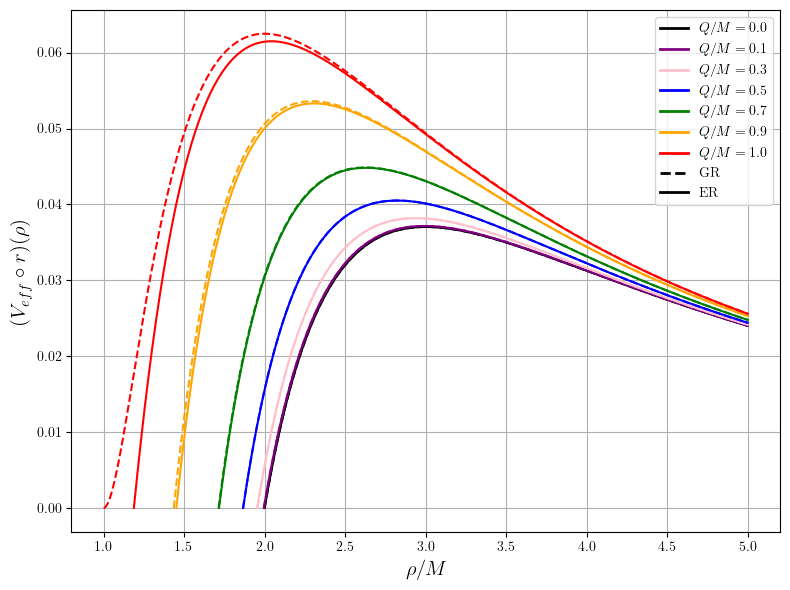

In [10]:
plt.figure(figsize=(8, 6))

for m, q, c, s in cases:
    rpGR, _ = rpm_GR(m, q)
    rpER, _ = rpm_ER(m, q)
    
    r_GR = np.linspace(rpGR, 5 * m, 1000)
    r_GR_norm = r_GR / m

    rhopER = rho_ER(rpER, m, q)
    rhoER = np.linspace(rhopER, 5 * m, 1000)
    rhoER_norm = rhoER / m

    r_ER = np.array([r_coord(rho, m, q) for rho in rhoER])
    
    Vgr = np.array([Veff_GR(r, m, q) for r in r_GR])
    Ver = np.array([Veff_ER(r, m, q) for r in r_ER])

    plt.plot(r_GR_norm, Vgr, '--', color=c)
    plt.plot(rhoER_norm, Ver, '-', color=c)


plt.legend(handles=handles,loc="upper right", fontsize=10)

plt.grid()
plt.xlabel(r'$\rho/ M$', fontsize=15)
plt.ylabel(r'$(V_{eff} \circ r)(\rho)$', fontsize=15)

plt.tight_layout()
plt.savefig("images/EffectivePotentials_Mass.png", dpi=150, bbox_inches='tight')

## 4 - Photon Sphere

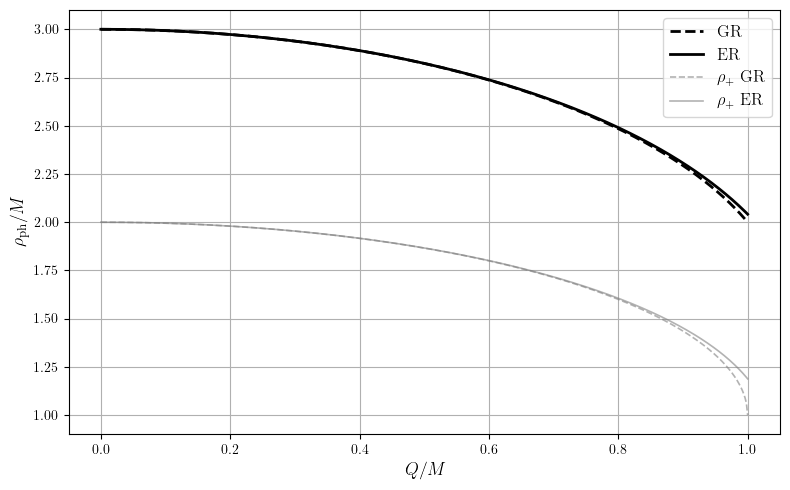

In [11]:
## 4 - Photon Sphere Radius vs Charge

M_val = 1.0
Q_arr = np.linspace(0, 1.0, 500)

# ── Analytical photon sphere in GR (Reissner-Nordström) ───────────────────────
def r_photon_GR(M, Q):
    return (3*M + np.sqrt(np.maximum(9*M**2 - 8*Q**2, 0))) / 2

# ── Numerical photon sphere in ER via dV/dr = 0 ───────────────────────────────
def r_photon_ER(M, Q):
    rp, rm = rpm_ER(M, Q)
    a = (35/13) * rm + 3 * rp
    b = 8 * (48/13) * rm * rp
    return (1/4) * (a + np.sqrt(a**2 - b))

# ── Compute ρ_ph and ρ_+ for each Q ──────────────────────────────────────────
rho_ph_GR   = np.array([rho_GR(r_photon_GR(M_val, Q), M_val, Q)  for Q in Q_arr])
rho_plus_GR = np.array([rho_GR(rpm_GR(M_val, Q)[0],   M_val, Q)  for Q in Q_arr])

r_ph_ER_arr = np.array([r_photon_ER(M_val, Q)                     for Q in Q_arr])
rho_ph_ER   = np.array([rho_ER(r, M_val, Q) if not np.isnan(r) else np.nan
                         for r, Q in zip(r_ph_ER_arr, Q_arr)])
rho_plus_ER = np.array([rho_ER(rpm_ER(M_val, Q)[0], M_val, Q)    for Q in Q_arr])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(Q_arr, rho_ph_GR, '--', color='black', lw=2, label='GR')
ax.plot(Q_arr, rho_ph_ER, '-',  color='black', lw=2, label='ER')
ax.plot(Q_arr, rho_plus_GR, '--', color='gray', lw=1.2, alpha=0.6, label=r'$\rho_+$ GR')
ax.plot(Q_arr, rho_plus_ER, '-',  color='gray', lw=1.2, alpha=0.6, label=r'$\rho_+$ ER')

ax.set_xlabel(r'$Q/M$', fontsize=13)
ax.set_ylabel(r'$\rho_{\mathrm{ph}} / M$', fontsize=13)
ax.legend(fontsize=12)
ax.grid()

plt.tight_layout()
plt.savefig("images/PhotonSphere_Mass.png", dpi=150, bbox_inches='tight')

## 5 - Weak Lensing

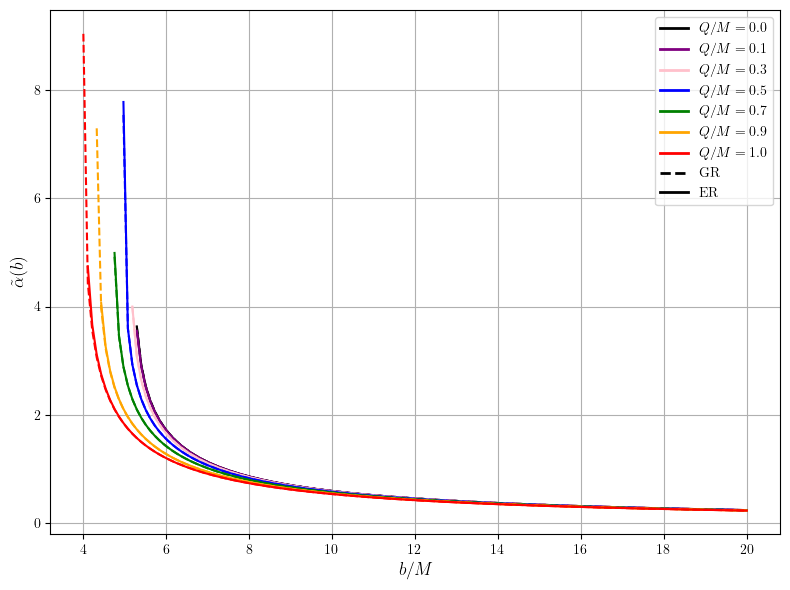

In [12]:
# ── Deflection angle α̃(b) for photons ────────────────────────────────────────

# C(r) = g_φφ at θ = π/2
def C_GR(r, M, Q):
    return r**2

def C_ER(r, M, Q):
    _, rm = rpm_ER(M, Q)
    return r**2 * (1 - rm/r)**(2/13)


def Vprime_num(Veff_func, r, M, Q):
    h = 1e-5 * max(1.0, abs(r))
    return (Veff_func(r + h, M, Q) - Veff_func(r - h, M, Q)) / (2*h)


def turning_point_from_b(Veff_func, rpm_func, rph_func, M, Q, b):
    """
    Finds the outer turning point r0 > r_ph such that V_eff(r0) = 1/b².
    Returns np.nan for captured photons.
    """
    rph = rph_func(M, Q)
    Vmax = Veff_func(rph, M, Q)
    bcrit = 1 / np.sqrt(Vmax)

    if b <= bcrit:
        return np.nan

    target = 1 / b**2

    # On the outer branch, V_eff decreases from Vmax to 0.
    lo = rph * (1 + 1e-10)
    hi = max(10*M, 2*b, 2*lo)

    f = lambda r: Veff_func(r, M, Q) - target

    # Expand upper bracket until V_eff(hi) < 1/b²
    while f(hi) > 0:
        hi *= 2
        if hi > 1e8 * M:
            return np.nan

    return brentq(f, lo, hi, xtol=1e-12, rtol=1e-12)


def deflection_angle_from_b(Veff_func, C_func, rpm_func, rph_func, M, Q, b):
    """
    Computes α̃(b) = 2 Δφ - π for a photon coming from infinity,
    reaching r0, then escaping back to infinity.
    """
    r0 = turning_point_from_b(Veff_func, rpm_func, rph_func, M, Q, b)

    if not np.isfinite(r0):
        return np.nan

    # Change variable:
    #   r = r0 / (1 - z²)
    # maps z ∈ [0,1] to r ∈ [r0,∞].
    # This removes the square-root singularity at r0.
    Vp0 = Vprime_num(Veff_func, r0, M, Q)
    C0 = C_func(r0, M, Q)

    def integrand(z):
        if z == 0:
            # finite limit at the turning point
            return 2*r0 / (C0 * np.sqrt(-Vp0 * r0))

        if z == 1:
            # asymptotic finite limit
            return 2*b / r0

        r = r0 / (1 - z**2)
        dr_dz = 2*r0*z / (1 - z**2)**2

        arg = 1 - b**2 * Veff_func(r, M, Q)

        # Roundoff protection very close to the turning point
        if arg <= 0:
            return 2*r0 / (C0 * np.sqrt(-Vp0 * r0))

        return b * dr_dz / (C_func(r, M, Q) * np.sqrt(arg))

    delta_phi, err = quad(
        integrand,
        0.0,
        1.0,
        epsabs=1e-9,
        epsrel=1e-9,
        limit=200
    )

    return 2*delta_phi - np.pi


# ── Critical impact parameters ────────────────────────────────────────────────
theory_deflection_data = [
    ("GR", Veff_GR, C_GR, rpm_GR, r_photon_GR, '--'),
    ("ER", Veff_ER, C_ER, rpm_ER, r_photon_ER, '-'),
]

bcrit_values = {}

for M_val, Q_val, color, label in cases:
    for theory_name, Veff_func, C_func, rpm_func, rph_func, linestyle in theory_deflection_data:
        rph = rph_func(M_val, Q_val)
        bcrit = 1 / np.sqrt(Veff_func(rph, M_val, Q_val))
        bcrit_values[(theory_name, Q_val/M_val)] = bcrit / M_val


# ── Choose b/M sampling ───────────────────────────────────────────────────────
bcrit_min = min(bcrit_values.values())
bcrit_max = max(bcrit_values.values())

# Start slightly below the smallest bcrit.
# Curves will automatically be NaN/captured until their own bcrit.
b_min = 1.001 * bcrit_min
b_max = 20.0
n_b = 150

b_over_M_arr = np.linspace(b_min, b_max, n_b)


# ── Compute and plot α̃(b) ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for M_val, Q_val, color, label in cases:

    for theory_name, Veff_func, C_func, rpm_func, rph_func, linestyle in theory_deflection_data:

        alpha_arr = []

        for b_over_M in b_over_M_arr:
            b = b_over_M * M_val

            alpha = deflection_angle_from_b(
                Veff_func,
                C_func,
                rpm_func,
                rph_func,
                M_val,
                Q_val,
                b
            )

            alpha_arr.append(alpha)

        alpha_arr = np.array(alpha_arr)

        ax.plot(
            b_over_M_arr,
            alpha_arr / (2*np.pi),
            color=color,
            linestyle=linestyle,
            lw=1.5
        )


# ── Legends ──────────────────────────────────────────────────────────────────

ax.legend(handles=handles,loc="upper right", fontsize=10)

ax.set_xlabel(r'$b/M$', fontsize=13)
ax.set_ylabel(r'$\tilde{\alpha}(b) / 2\pi$', fontsize=13)

ax.grid()

# Optional: useful if the divergence near bcrit dominates too much
# ax.set_ylim(0, 5)

plt.tight_layout()
#plt.savefig("images/DeflectionAngle_vs_ImpactParameter_Mass.png", dpi=150, bbox_inches='tight')